Shape: (398, 7)
Missing values: 0
    mpg  cylinders  displacement  horsepower  weight  acceleration  model_year
0  18.0          8         307.0       130.0    3504          12.0          70
1  15.0          8         350.0       165.0    3693          11.5          70
2  18.0          8         318.0       150.0    3436          11.0          70
3  16.0          8         304.0       150.0    3433          12.0          70
4  17.0          8         302.0       140.0    3449          10.5          70
X shape: (398, 6)
y shape: (398,)
X_train shape: (318, 6)
X_test shape: (80, 6)


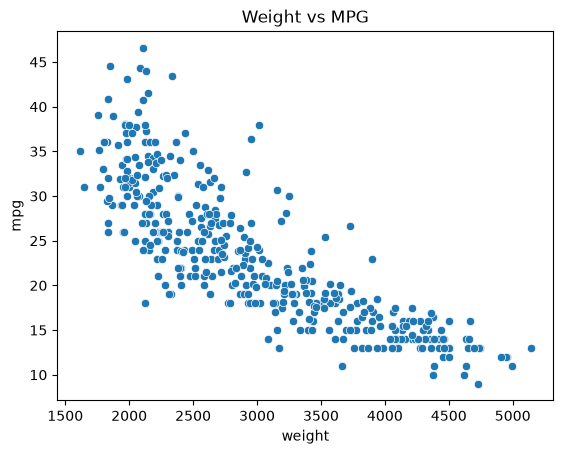


Predictions:
[32.77165335 26.29330219 26.22305501 16.0294085  13.71125152 30.39105443
 24.42004403  9.82424083 15.09277942 24.34199161 16.73188031 31.44476215
 31.52281457 16.40406013 26.94113731  8.10708751 26.68356431 22.27360238
 13.84394064 31.40573593 27.18309982 24.66981178 24.6542013  30.58618549
 19.43249417 30.15689716 29.10318944 25.39569932 20.16618695  8.48954439
 25.00543721 31.32768351 16.3416182  29.00172129 31.02327906 13.39123659
 27.48750427 20.04910831 11.67408327 29.46223059 25.70790902 32.46724889
 23.88928755 10.76086991 27.22212603 29.92273989 29.25148904 25.93426105
 28.24461278 29.43100962 27.98703978 31.36670972 28.90805838 12.26728169
 25.51277796 11.93946151 16.0294085  25.62205135 29.11099468 21.30575233
 18.18365539 32.77165335 26.1840288  23.5302464  24.11563958 29.39198341
 24.49809645 30.82034276 29.89151892 14.79618021 29.49345156 13.55514668
 12.89950632 23.66293552 23.79562464 20.51742285 19.30761029 26.44940704
 31.66330893 16.80993274]

Actual vs 

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


# Load dataset
t = pd.read_csv('mpg.csv')

# Remove unnecessary columns
t = t.drop(columns=['name', 'origin'])

# Handle missing values
t['horsepower'] = t['horsepower'].fillna(t['horsepower'].median())

# Display dataset information
print("Shape:", t.shape)
print("Missing values:", t.isna().sum().sum())
print(t.head())


# Separate features and target
X = t.drop(columns=['mpg'])
y = t['mpg']

print("X shape:", X.shape)
print("y shape:", y.shape)


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


# Scatter plot
sns.scatterplot(data=t, x='weight', y='mpg')
plt.title('Weight vs MPG')
plt.show()


# Create and train Linear Regression model
model = LinearRegression()

# Using only weight as the input feature
model.fit(X_train[['weight']], y_train)


# Make predictions
y_pred = model.predict(X_test[['weight']])

print("\nPredictions:")
print(y_pred)


# Actual vs Predicted
result = pd.DataFrame({
    'Actual MPG': y_test.values,
    'Predicted MPG': y_pred
})

print("\nActual vs Predicted:")
print(result)



print("\nSlope:", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nEquation:")
print(f"MPG = {model.coef_[0]:.4f} × Weight + {model.intercept_:.4f}")



mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MSE:", mse)
print("R² Score:", r2)

In [6]:
print("\nModel Evaluation:")
print("MSE:", mse)
print("R² Score:", r2)


Model Evaluation:
MSE: 14.894861064636194
R² Score: 0.722971057303075


In [17]:
from sklearn.linear_model import LinearRegression

model_all = LinearRegression()

model_all.fit(X_train, y_train)

print("Without scaling:", model_all.score(X_test, y_test))

Without scaling: 0.8244245330943358


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_scaled = LinearRegression()

model_scaled.fit(X_train_scaled, y_train)

print("With scaling:", model_scaled.score(X_test_scaled, y_test))


With scaling: 0.8244245330943358


In [20]:
pd.DataFrame({
    'feature': X_train.columns,
    'coef without scaling': model_all.coef_.round(3),
    'coef with scaling': model_scaled.coef_.round(3)
})

,feature,coef without scaling,coef with scaling
0,cylinders,0.069,0.116
1,displacement,0.002,0.165
2,horsepower,0.003,0.107
3,weight,-0.007,-5.912
4,acceleration,0.081,0.222
5,model_year,0.801,2.883


In [21]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()
knn.fit(X_train,y_train)
acc_knn_raw=knn.score(X_test,y_test)
print(acc_knn_raw)

0.7659996807953288


In [25]:
knn_model_scaled = KNeighborsRegressor(n_neighbors=5)
knn_model_scaled.fit(X_train_scaled, y_train)
acc_knn_scaled = knn_model_scaled.score(X_test_scaled, y_test)
pd.DataFrame({
    'model': [
        'LinearRegression',
        'knn regressor (no scaling)',
        'knn regressor (scaler)'
    ],

    'R2': [
        round(model_all.score(X_test, y_test), 4),
        round(acc_knn_raw, 4),
        round(acc_knn_scaled, 4)
    ]
})

,model,R2
0,LinearRegression,0.8244
1,knn regressor (no scaling),0.7660
2,knn regressor (scaler),0.8785
